# CHICKEN EGG FERTILITY DETECTION
Jon Kalvin Estilong

# Environment Setup

In [ ]:
# Reference: Dr. John Paul Tomas - Coin Detection Final.ipynb, Cell 1
from google.colab import drive # This imports the Google Drive module specifically for Colab. It's what lets us connect to our Google Drive storage.

drive.mount('/content/drive')# This mounts (connects) your Google Drive to this Colab notebook. After running this, you'll get a link to authorize access and then you can access all your files from Drive like they're local.

Mounted at /content/drive


In [ ]:
#!pip install ultralytics
# This installs the ultralytics library which has YOLO - the object detection model we need for detecting eggs in images and video.
!pip install -U ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 79.8 MB/s eta 0:00:00


## Data .yaml file Verification

In [ ]:
import yaml  #PyYAML documentation: https://pyyaml.org/wiki/PyYAMLDocumentation. This is for reading the data.yaml file that has all my dataset info. Been using this since my earlier ML projects.
import os  # Python os.path documentation: https://docs.python.org/3/library/os.path.html. This lets me check if folders actually exist and handle file paths. Pretty basic stuff we use all the time.

# This is where I saved my data.yaml file in Google Drive from the last activity
yaml_path = "/content/drive/MyDrive/machine-learning/annotated-dataset/With_Augmentation/data.yaml"

# Gotta check if the file is actually there first - learned this after getting way too many file not found errors lol
if os.path.exists(yaml_path):

    # Opening the yaml file to read it. The 'with' thing automatically closes it so no need to worry about that.
    with open(yaml_path, 'r') as f:

        # This loads everything from the yaml into a dictionary so I can easily grab what I need
        data = yaml.safe_load(f)

    # Just printing everything to double check it loaded right. Helps catch any typos in the file.
    print("data.yaml contents:")
    print(data)

    # Getting the path to my training images from the yaml file.Reference, https://docs.ultralytics.com/datasets/detect/
    train_path = data['train']
    print("\nTrain path:", train_path)

    # The path in yaml has ../ in it so I need to build the full path. Took me a while to figure this out honestly.
    full_train = os.path.join(os.path.dirname(yaml_path), train_path.replace('../', ''))
    print("Full train path:", full_train)

    # Making sure the training folder actually exists. Would suck to start training and realize it's missing.
    if os.path.exists(full_train):
        print("Train folder exists")

        # Counting how many images I have for training
        images = os.listdir(full_train)
        print("Images in train:", len(images))
    else:
        print("Train folder missing")

    # Same thing but for validation data. Need this to check how the model performs.
    val_path = data['val']
    print("\nVal path:", val_path)

    # Building the full validation path the same way as train
    full_val = os.path.join(os.path.dirname(yaml_path), val_path.replace('../', ''))
    print("Full val path:", full_val)

    # Checking if validation folder exists. Can't validate without validation data obviously.
    if os.path.exists(full_val):
        print("Validation folder exists")

        # Counting validation images to make sure I have enough for proper testing
        images = os.listdir(full_val)
        print("Images in validation:", len(images))
    else:
        print("Validation folder missing")

    # Number of classes I'm detecting - in this case it's 2 (fertile and infertile eggs)
    print("\nNumber of classes:", data['nc'])

    # The actual class names. Good to double check these are right.
    print("Class names:", data['names'])

    # Quick summary so I can see everything's set up properly at a glance
    print("Classes:", data['nc'], "-", data['names'][0], "and", data['names'][1])

else:
    # Error message if file isn't found. Happens sometimes when I mess up the path.
    print("data.yaml not found at", yaml_path)

data.yaml contents:
{'train': '../train/images', 'val': '../valid/images', 'test': '../test/images', 'nc': 2, 'names': ['fertile', 'infertile'], 'roboflow': {'workspace': 'nodkeyobma', 'project': 'egg-fertility-candling', 'version': 7, 'license': 'CC BY 4.0', 'url': 'https://universe.roboflow.com/nodkeyobma/egg-fertility-candling/dataset/7'}}

Train path: ../train/images
Full train path: /content/drive/MyDrive/machine-learning/annotated-dataset/With_Augmentation/train/images
Train folder exists
Images in train: 2340

Val path: ../valid/images
Full val path: /content/drive/MyDrive/machine-learning/annotated-dataset/With_Augmentation/valid/images
Validation folder exists
Images in validation: 331

Number of classes: 2
Class names: ['fertile', 'infertile']
Classes: 2 - fertile and infertile


#DATASET LINK IN MY ROBOBFLOW

https://universe.roboflow.com/nodkeyobma/egg-fertility-candling/dataset/7

# Model Initialization & Training

In [ ]:
# Reference: Dr. John Paul Tomas - Coin Detection Final.ipynb
from ultralytics import YOLO  # This imports the YOLO class from the ultralytics library. It's what we need to load and train the object detection model.https://github.com/ultralytics/ultralytics

# MODEL A- AdamW optimizer, batch size 4, learning rate 0.01, 25 epochs

print("Training Model A - AdamW, Batch 4, LR 0.01, Epochs 25")  # Just letting myself know which experiment is running

model1 = YOLO("yolo26n.pt")  # Loading the pre-trained YOLO model. The 'n' stands for nano which is the smallest version, good for starting out.https://github.com/ultralytics/ultralytics

train_results1 = model1.train(
    data="/content/drive/MyDrive/machine-learning/annotated-dataset/With_Augmentation/data.yaml",  # Path to my dataset configuration file that tells the model where images are
    epochs=25,           # Number of times the model will go through the entire dataset. 25 is decent for seeing how well it learns.
    imgsz=640,           # Resizes all images to 640x640 pixels. YOLO works best with consistent image sizes.
    batch=4,             # Processes 4 images at a time. Smaller batch size means slower but more stable training.
    optimizer='AdamW',    # AdamW is an optimization algorithm that helps the model learn faster by adjusting learning rates.
    lr0=0.01,            # Initial learning rate - controls how much the model changes with each step. 0.01 is pretty standard.
    plots=True           # This generates loss graphs in real-time so I can watch the training progress.
)

print("Model A completed")  # Simple confirmation that the first experiment finished running

Training Model A - AdamW, Batch 4, LR 0.01, Epochs 25
Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/machine-learning/annotated-dataset/With_Augmentation/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=25, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train

In [ ]:
# Reference: Dr. John Paul Tomas - Coin Detection Final.ipynb
# MODEL B SGD optimizer, batch size 20, learning rate 0.001, 30 epochs

print("Training Model B - SGD, Batch 20, LR 0.001, Epochs 30")  # Prints which configuration is running so I don't get confused between experiments

model2 = YOLO("yolo26n.pt")  # Loading another fresh pre-trained YOLO model for the second experiment. Using the same starting point for fair comparison.

train_results2 = model2.train(
    data="/content/drive/MyDrive/machine-learning/annotated-dataset/With_Augmentation/data.yaml",  # Same dataset path as first experiment so results are comparable
    epochs=30,           # Running for 30 epochs - 5 more than model A to see if more training time improves detection
    imgsz=640,           # Keeping image size the same across all experiments for consistent comparison
    batch=20,            # Medium batch size - faster than batch 4 but might be less stable. Good for seeing how batch size affects training
    optimizer='SGD',      # Using SGD (Stochastic Gradient Descent) optimizer. Older but simpler than Adam, good for comparison
    lr0=0.001,           # Lower learning rate at 0.001 because SGD typically needs smaller steps than Adam optimizers
    plots=True           # Generates loss graphs so I can compare how this model learns against the first one
)

print("Model B completed")  # Confirmation that the second experiment finished running

Training Model B - SGD, Batch 20, LR 0.001, Epochs 30
Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=20, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/machine-learning/annotated-dataset/With_Augmentation/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=tra

In [ ]:
# Reference: Dr. John Paul Tomas - Coin Detection Final.ipynb
# MODEL C- Auto optimizer, auto batch, learning rate 0.0001, 40 epochs
from ultralytics import YOLO
print("Training Model C - Auto Optimizer, Auto Batch, LR 0.0001, Epochs 40")  # Prints which configuration is running so I can track progress

model3 = YOLO("yolo26n.pt")  # Loading another fresh pre-trained YOLO model for the third experiment. Same starting point for all models.

train_results3 = model3.train(
    data="/content/drive/MyDrive/machine-learning/annotated-dataset/With_Augmentation/data.yaml",  # Same dataset path across all experiments for fair comparison
    epochs=40,           # Running for 40 epochs - longest training to see if more epochs lead to better results
    imgsz=640,           # Keeping image size consistent at 640 across all three experiments
    batch=-1,            # Auto-batching lets YOLO figure out the best batch size based on available GPU memory - pretty convenient
    optimizer='auto',     # Auto optimizer lets YOLO choose between SGD and Adam based on what works best for my dataset
    lr0=0.0001,          # Very small learning rate - good for fine-tuning when the model is close to optimal performance
    plots=True           # Generates loss graphs to compare training progress against the other two models
)

print("Model C completed")  # Confirmation that the third experiment finished running

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Training Model C - Auto Optimizer, Auto Batch, LR 0.0001, Epochs 40
Ultralytics 8.4.16 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=-1, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/machine-learning/annotated-dataset/With_Augmentation/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=40, erasing=0.4, exist_ok=False, fliplr=

In [ ]:
# BACKUPING FILES FROM RUNTIME FOLDER TO MY DRIVE.THE REASON IS THAT ALL FOLDERS WILL BE DELETED IN THE RUNTIME AFTER IT DISCONNECTED
import shutil  # This module lets me copy and move files around, kind of like drag and drop but in code
import os  # This helps me check if files and folders exist and work with file paths

# Source path - where the runs folder currently is in Colab's temporary storage
source_path = "/content/runs"

# Destination path - where I want to save it in my Google Drive so I don't lose it
destination_path = "/content/drive/MyDrive/machine-learning/runs"

# Check if source exists - don't want to try copying something that isn't there
if os.path.exists(source_path):
    # Copy the entire runs folder to MyDrive - this keeps all my training results safe
    shutil.copytree(source_path, destination_path)
    print("Runs folder successfully copied to:", destination_path)
else:
    print("Runs folder not found at", source_path)

Runs folder successfully copied to: /content/drive/MyDrive/machine-learning/runs


# Model Evaluation (The Confusion Matrix)

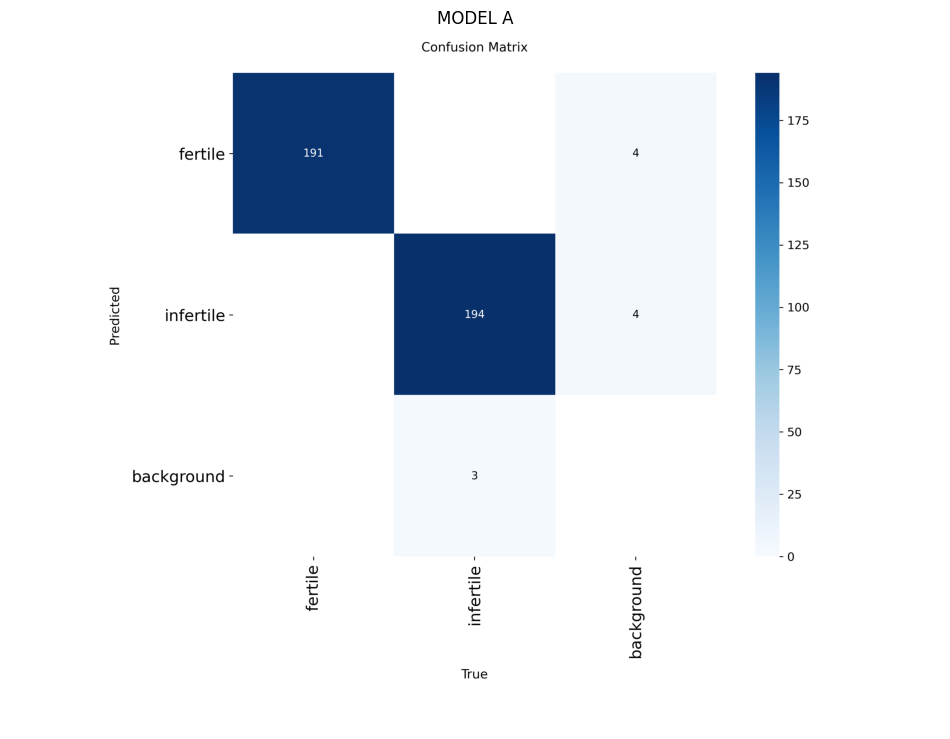

In [ ]:
import matplotlib.pyplot as plt  # This is for displaying images and making plots. Used it before in other subjects.
import cv2  # OpenCV library for reading images. Pretty standard for image processing tasks.

# Path to confusion matrix - this is where YOLO saved the confusion matrix from my training
confusion_matrix_path = "/content/runs/detect/train/confusion_matrix.png"

# Load and display the image
img = cv2.imread(confusion_matrix_path)  # Reads the image file. cv2 reads images in BGR format by default.
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Converts from BGR to RGB so colors display correctly. matplotlib uses RGB.
plt.figure(figsize=(12, 10))  # Makes the figure bigger so it's easier to read the numbers
plt.imshow(img_rgb)  # Actually displays the image in the plot
plt.title("MODEL A")  # Title so I know what I'm looking at
plt.axis('off')  # Removes the axis numbers since we just want to see the matrix
plt.show()  # Shows the plot in the notebook

When it comes to distinguishing between the two types of eggs that are important to us—the fertile eggs and the infertile eggs—Model A is really rather excellent. The matrix properly detected 194 infertile eggs and 191 fertile eggs if you look at the diagonal. These are legitimately high figures, indicating that the model does a great job at differentiating between these two groups and correctly labeling them.
But when it comes to the "background" class, the model kind of falls short. In essence, it is less accurate at identifying when there isn't an egg at all.
This is where the errors occur: Four background samples were mistaken for fertile eggs and four for infertile ones by the model, which had some false positives where it believed background material to be an egg. In other words, it's essentially seeing eggs where none exist. However, there were also occasional false negatives, in which three infertile eggs were entirely overlooked and were classified as background.
The model is excellent at its primary function, which is to determine if an egg is fertile or infertile once it detects the presence of an egg. However, it still has trouble telling the difference between real eggs and background noise for the entire "is this even an egg?" section.


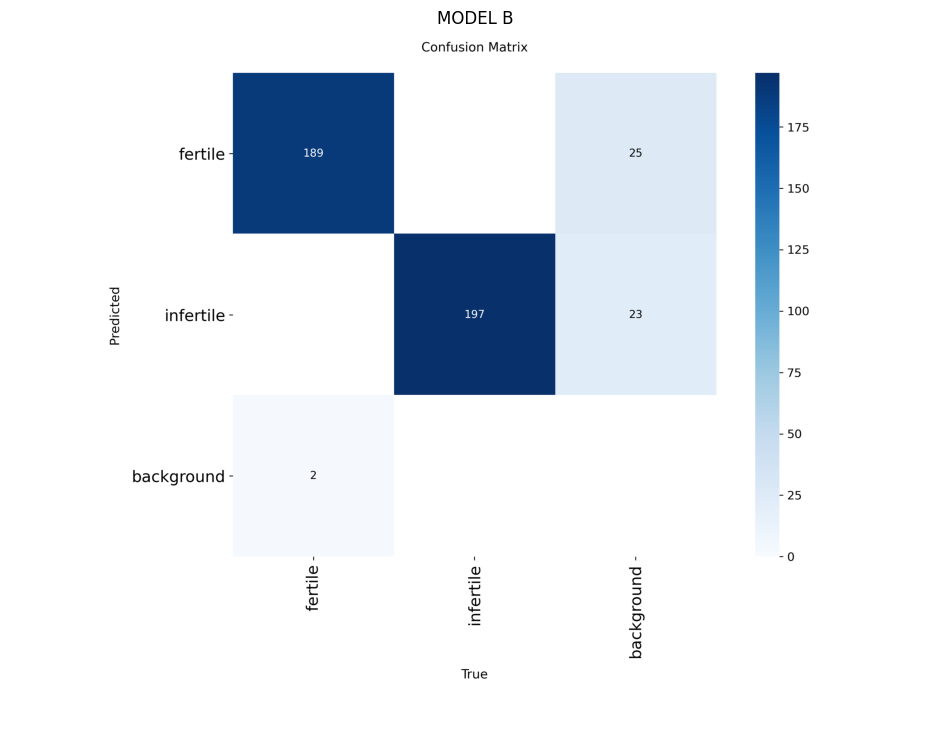

In [ ]:
# Path to confusion matrix - this is where YOLO saved the confusion matrix from my training
confusion_matrix_path = "/content/runs/detect/train2/confusion_matrix.png"

# Load and display the image
img = cv2.imread(confusion_matrix_path)  # Reads the image file. cv2 reads images in BGR format by default.
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Converts from BGR to RGB so colors display correctly. matplotlib uses RGB.
plt.figure(figsize=(12, 10))  # Makes the figure bigger so it's easier to read the numbers
plt.imshow(img_rgb)  # Actually displays the image in the plot
plt.title("MODEL B")  # Title so I know what I'm looking at
plt.axis('off')  # Removes the axis numbers since we just want to see the matrix
plt.show()  # Shows the plot in the notebook

When it comes to the main work, Model B is still rather strong. The diagonal values, 189 for fertile eggs and 197 for infertile eggs, are still accurate. It is thus still quite good at classifying them after it recognizes that it is gazing at an egg.
The issue is that its background game is far inferior than that of the Model A. More and more confusion is occurring.
False positives have increased dramatically. The backdrop was perceived by the model as a fertile egg 25 times and an infertile egg 23 times. This implies that it sees eggs that aren't present all the time. The primary problem is all these additional, inaccurate detections, but it did miss a few fertile eggs (false negatives).
Although Model B is still able to distinguish between excellent and poor eggs, it is having a lot of trouble determining what constitutes an egg in the first place. It's classifying random background items as eggs, which leads to a lot of errors. All those false positives would be a major issue in the actual world and significantly reduce the model's credibility. There is undoubtedly more work or fine-tuning needed.

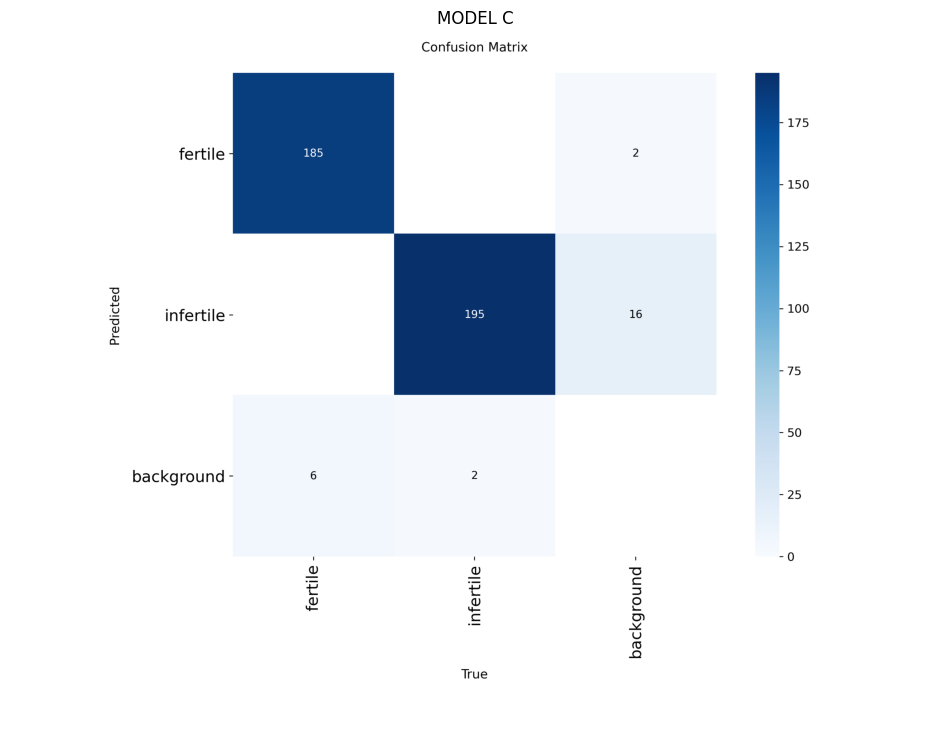

In [ ]:
# Path to confusion matrix - this is where YOLO saved the confusion matrix from my training
confusion_matrix_path = "/content/runs/detect/train3/confusion_matrix.png"

# Load and display the image
img = cv2.imread(confusion_matrix_path)  # Reads the image file. cv2 reads images in BGR format by default.
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Converts from BGR to RGB so colors display correctly. matplotlib uses RGB.
plt.figure(figsize=(12, 10))  # Makes the figure bigger so it's easier to read the numbers
plt.imshow(img_rgb)  # Actually displays the image in the plot
plt.title("MODEL C")  # Title so I know what I'm looking at
plt.axis('off')  # Removes the axis numbers since we just want to see the matrix
plt.show()  # Shows the plot in the notebook

Model C's confusion matrix demonstrates excellent classification performance for the two primary egg groups. 185 correctly predicted fertile eggs and 195 correctly predicted infertile eggs are shown by the diagonal values, which show that the model is capable of differentiating between these two classes. According to these high true positive values, the model continues to maintain consistent learning in both categories and good internal class separation.

First, false positives occur when the background is mistaken for an egg, which is nearly invariably an infertile egg. This was done sixteen times. Only twice did it believe the backdrop to be a fertile egg. Therefore, the model has a severe bias: if it is uncertain and detects a fake egg, it will classify it as infertile.
The false negatives came next: It also failed to detect several actual eggs. Two infertile eggs were considered background, while six fertile eggs were considered background.
What's the conclusion, then? Model C is far more adept at preventing random eggs from appearing everywhere than Model B (fewer total false positive). Its primary flaw, though, is that it has a major quirk where it truly wants to call its errors "infertile." It performs admirably with the actual eggs, but in order to make it deployment-ready, we would need to adjust the threshold or provide it with more background examples to address that peculiar infertile bias.

# Generating the Performance Table

In [ ]:
# Import the YOLO class from Ultralytics library
# This lets me load and use YOLO models for object detection
# https://docs.ultralytics.com/guides/yolo-performance-metrics/#how-to-calculate-metrics-for-yolo26-model
from ultralytics import YOLO
import pandas as pd

# List of my trained model names
# These are folder names inside 'runs/detect/' where my training results are saved
# I trained 3 different versions, so I want to compare them all
models = ["train", "train2", "train3"]
# Path to my dataset configuration file
# This YAML file tells YOLO where my test images are and what classes I have
# It's like a map that points to all my data
data_yaml = "/content/drive/MyDrive/machine-learning/annotated-dataset/With_Augmentation/data.yaml"
# =================

results = []
 # Loop through each model in my list
    # First time: model_name = "train"
    # Second time: model_name = "train2"
    # Third time: model_name = "train3"
for model_name in models:
    print(f"Testing {model_name}...")

      # Load my trained model from the weights file
    # 'best.pt' is the best checkpoint saved during training
    # .pt means PyTorch model file
    # Path breakdown:
    #   runs/detect/ - main folder where YOLO saves everything
    #   {model_name}/ - subfolder for this specific training run
    #   weights/best.pt - the actual model weights file
    model = YOLO(f"runs/detect/{model_name}/weights/best.pt")

    # This evaluates how well my model performs on images it hasn't seen before
    # model.val() returns a Metrics object with all performance numbers
    # data=data_yaml tells it which dataset to use
    metrics = model.val(data=data_yaml)

    # Get results
     # metrics.box.map50 accesses the mAP50 value from the results
    mAP50 = round(metrics.box.map50, 4)
    precision = round(metrics.box.mp, 4)
    recall = round(metrics.box.mr, 4)

    # Calculate F1
    if precision + recall > 0:
        f1 = round(2 * (precision * recall) / (precision + recall), 4)
    else:
        f1 = 0
    # Add this model's results to my list
    # Each entry is a list: [model_name, mAP50, precision, recall, f1]
    # After all loops, results will have 3 rows (one per model)
    results.append([model_name, mAP50, precision, recall, f1])

# Convert my list of results into a pandas DataFrame (like a spreadsheet)
# pd.DataFrame() creates a table from my data
# columns=... gives names to each column
# Now I have a nice organized table with rows = models, columns = metrics
performance_table = pd.DataFrame(results, columns=["Model", "mAP50", "Precision", "Recall", "F1"])

# Replace the original folder names with cleaner labels
# "train" becomes "Model A", "train2" becomes "Model B", etc.
performance_table["Model"] = ["Model A", "Model B", "Model C"]

# In Jupyter/Colab, just writing the variable name at the end displays it
# This shows my beautiful comparison table!
performance_table

Testing train...
Ultralytics 8.4.16 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26n summary (fused): 122 layers, 2,375,226 parameters, 0 gradients, 5.2 GFLOPs
val: Fast image access ✅ (ping: 0.8±0.3 ms, read: 13.2±4.7 MB/s, size: 19.7 KB)
val: Scanning /content/drive/MyDrive/machine-learning/annotated-dataset/With_Augmentation/valid/labels.cache... 331 images, 1 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 331/331 92.6Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 21/21 4.4it/s 4.8s
                   all        331        388      0.994      0.984      0.993      0.874
               fertile        185        191      0.993          1      0.995       0.88
             infertile        162        197      0.995      0.968      0.991      0.867
Speed: 2.5ms preprocess, 4.8ms inference, 0.0ms loss, 0.3ms postprocess per image
Results saved to /content/runs/detect/val
Testing train2...
Ultralytic

,Model,mAP50,Precision,Recall,F1
0,Model A,0.9927,0.9940,0.9842,0.9891
1,Model B,0.9860,0.9595,0.9558,0.9576
2,Model C,0.9913,0.9536,0.9830,0.9681


# MODEL'S RESULT DISCUSSION

Based on their performance outcomes, each of the three models (Model A, Model B, and Model C) handles the identification of fertile and infertile classes differently. Model A performs exceptionally well in detecting situations, exhibiting excellent accuracy in both classes with an accuracy of 0.999 and recall of 0.984. Conversely, infertile detection works somewhat better, with an precision of 0.995 and a recall of 0.991.
Model B, on the other hand, performs noticeably worse on the infertile class, with precision of 0.986 and accuracy of 0.991, both of which are lower than those of Model A. With accuracy of 0.998 and recall of 0.996, Model B continues to perform at a fair level on the fertile class in spite of these difficulties. For both kinds of eggs, Model C is quite accurate. In both areas, its performance is nearly comparable. It captures 99.6% of all real infertile eggs and is 99.6% accurate for infertile eggs. It is 99.9% accurate and captures 99.2% of fertile eggs. Both groups perform almost flawlessly, with fertile eggs having a slight advantage in accuracy and infertile eggs having a slight advantage in recall. All things considered, both Model A and Model C continue to perform well, with Model C being the most balanced in detecting both classes and Model B having more difficulty identifying infertile cases. The general trend here is that the majority of models are rather good at identifying whether an egg is fertile. However, some models do a terrible job of detecting infertile eggs. The largest culprit is Model B, which finds it especially difficult to accurately detect infertile individuals.


In [ ]:
import pandas as pd
# Imports the pandas library. Used for creating and displaying data tables.

hyperparams_data = [
    # Creates a list of dictionaries. Each dictionary stores one model's hyperparameters.

    {
        "Model": "Model A",
        # Name identifier for the first model. Matches the names used in my performance comparison table.

        "Weights Used": "yolo26n.pt",
        # Pre-trained weights I started training from. yolo26n.pt is the smallest nano version.

        "Epochs": 25,
        # Number of complete passes through the training dataset. Each epoch processes all images once.

        "Image Size": 640,
        # Input image resolution in pixels. YOLO resizes all images to 640×640.

        "Batch Size": 4,
        # Number of images processed before updating model weights. Smaller batch uses less GPU memory.

        "Optimizer": "AdamW",
        # Algorithm that updates weights during training. AdamW is a popular modern optimizer.

        "Learning Rate (lr0)": 0.01
        # Controls how much weights change each step. 0.01 means 1% adjustment per update.
    },

    {
        "Model": "Model B",
        # Name identifier for the second model. Used to compare against Model A and C.

        "Weights Used": "yolo26n.pt",
        # Same starting weights as Model A. Ensures fair comparison between models.

        "Epochs": 30,
        # Trained for 5 more epochs than Model A. Longer training can improve accuracy.

        "Image Size": 640,
        # Same image size as other models. Keeping this consistent across all experiments.

        "Batch Size": 20,
        # Much larger batch size than Model A. Processes 20 images before each update.

        "Optimizer": "SGD",
        # Stochastic Gradient Descent optimizer. Simpler than AdamW but still effective.

        "Learning Rate (lr0)": 0.001
        # Smaller learning rate than Model A. 0.001 means more precise but slower learning.
    },

    {
        "Model": "Model C",
        # Name identifier for the third model. My longest training experiment.

        "Weights Used": "yolo26n.pt",
        # Same pre-trained weights as others. Starting from same point for fair comparison.

        "Epochs": 40,
        # Longest training duration at 40 epochs. Model sees each image 40 times.

        "Image Size": 640,
        # Standard image size maintained. No changes to input resolution.

        "Batch Size": "Auto (-1)",
        # Automatic batch size selection. YOLO chooses optimal batch based on hardware.

        "Optimizer": "Auto",
        # Automatic optimizer selection. YOLO picks best optimizer for my setup.

        "Learning Rate (lr0)": 0.0001
        # Smallest learning rate of all models. Very slow but stable training.
    }
]

hyperparameter_table = pd.DataFrame(hyperparams_data)
# Converts my list of dictionaries into a DataFrame. Creates a structured table with rows and columns.

hyperparameter_table
# Displays the table in Jupyter/Colab. Shows all hyperparameters organized for easy comparison.

,Model,Weights Used,Epochs,Image Size,Batch Size,Optimizer,Learning Rate (lr0)
0,Model A,yolo26n.pt,25,640,4,AdamW,0.0100
1,Model B,yolo26n.pt,30,640,20,SGD,0.0010
2,Model C,yolo26n.pt,40,640,Auto (-1),Auto,0.0001


# TESTING ON UNSEEN VIDEO


WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

video 1/1 (frame 1/1069) /content/drive/MyDrive/machine-learning/test video/testegg3.avi: 384x640 1 fertile, 56.9ms
video 1/1 (frame 2/1069) /content/drive/MyDrive/machine-learning/test video/testegg3.avi: 384x640 1 fertile, 9.7ms
video 1/1 (frame 3/1069) /content/drive/MyDrive/machine-learning/test video/testegg3.avi: 384x640 (no detections), 9.5ms
video 1/1 (frame 4/1069) /content/drive/MyDrive/machine-learning/test video/testegg3.avi: 384x640 1 fertil

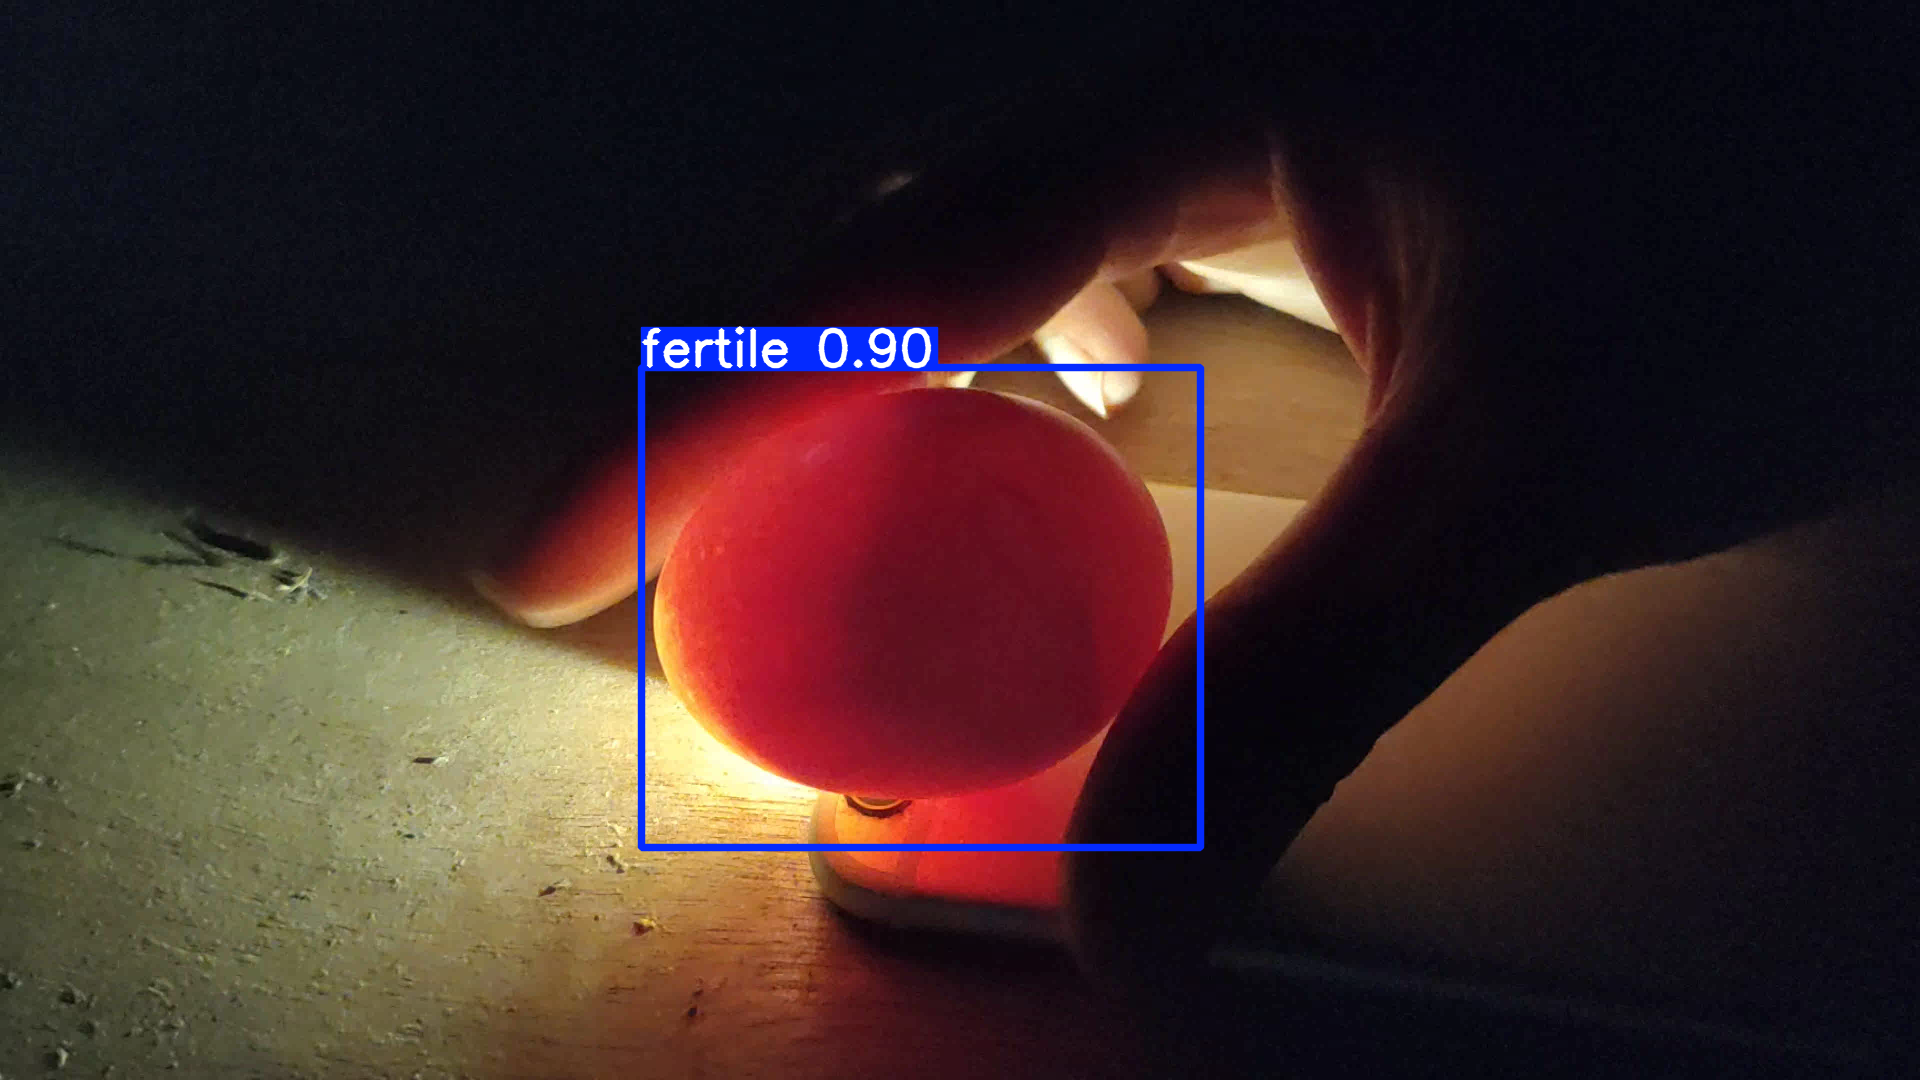

In [ ]:
# Reference: Dr. John Paul Tomas - Coin Detection Final.ipynb
#start from here after the training

from ultralytics import YOLO
model = YOLO("/content/runs/detect/train/weights/best.pt")
results = model("/content/drive/MyDrive/machine-learning/test video/testegg3.avi", save=True)
results[0].show()

#REFERENCES

-Dr. John Paul Tomas - Coin Detection Final.ipynb

-https://github.com/ultralytics/assets/releases/download/v8.4.0/yolo26n.pt

-https://pyyaml.org/wiki/PyYAMLDocumentation

-https://docs.python.org/3/library/os.path.html

-https://docs.ultralytics.com/datasets/detect/

-https://docs.ultralytics.com/guides/yolo-performance-metrics/#how-to-calculate-metrics-for-yolo26-model

-https://pandas.pydata.org/docs/

https://github.com/ultralytics/ultralytics
